<a href="https://colab.research.google.com/github/HimakshiNama/Bank_Finance_Project_python/blob/main/python_Fin_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BANK LOAN ANALYSIS REPORT

### Import Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px


In [17]:
df = pd.read_excel("/content/financial_loan.xlsx")
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [18]:
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,2021-07-11,2021-05-16,2021-05-16,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


In [19]:
print("No. of Rows",df.shape[0])

No. of Rows 38576


In [20]:
print("No. of Columns",df.shape[1])

No. of Columns 24


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

In [22]:
df.dtypes

,0
id,int64
address_state,object
application_type,object
emp_length,object
emp_title,object
grade,object
home_ownership,object
issue_date,datetime64[ns]
last_credit_pull_date,datetime64[ns]
last_payment_date,datetime64[ns]


In [23]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


### Total Loan Applications.

In [24]:
total_loan_applications = df["id"].count()
print("total_loan_applications:",total_loan_applications)

total_loan_applications: 38576


In [25]:
latest_issue_date = df["issue_date"].max()
latest_issue_year = latest_issue_date.year
latest_issue_month = latest_issue_date.month
mtd_data = df[(df['issue_date'].dt.year ==latest_issue_year) & (df['issue_date'].dt.month == latest_issue_month)]

mtd_loan_applications = mtd_data['id'].count()

print(f"MTD loan applications (for  {latest_issue_date.strftime('%B %Y')}): {mtd_loan_applications}")

MTD loan applications (for  December 2021): 4314


### Total Funded Amount


In [26]:
total_funded_amount= df["loan_amount"].sum()
total_funded_amount = total_funded_amount / 1000000
print(f"total_funded_amount:${total_funded_amount:,.2f}M")


total_funded_amount:$435.76M


MTD Total Funded Amount


In [27]:
latest_issue_date = df["issue_date"].max()
latest_issue_year = latest_issue_date.year
latest_issue_month = latest_issue_date.month
mtd_data = df[(df['issue_date'].dt.year ==latest_issue_year) & (df['issue_date'].dt.month == latest_issue_month)]

mtd_loan_applications = mtd_data['id'].count()

mtd_total_funded_amount = mtd_data["loan_amount"].sum()
mtd_total_funded_amount = mtd_total_funded_amount / 1000000
print(f"MTD loan applications (for  {latest_issue_date.strftime('%B %Y')}): {mtd_loan_applications}")
print(f"MTD total funded amount:${mtd_total_funded_amount:,.2f}M")

MTD loan applications (for  December 2021): 4314
MTD total funded amount:$53.98M


## Total Amount Received

In [28]:
total_amount_received= df["total_payment"].sum()
total_amount_received = total_amount_received / 1000000
print(f"total_amount_received:${total_amount_received:,.2f}M")


total_amount_received:$473.07M


 ## MTD Total Amount Received


In [29]:
latest_issue_date = df["issue_date"].max()
latest_issue_year = latest_issue_date.year
latest_issue_month = latest_issue_date.month
mtd_data = df[(df['issue_date'].dt.year ==latest_issue_year) & (df['issue_date'].dt.month == latest_issue_month)]

mtd_total_amount_received = mtd_data["total_payment"].sum()
mtd_total_amount_received = mtd_total_amount_received / 1000000

print(f"MTD loan applications (for  {latest_issue_date.strftime('%B %Y')}): {mtd_loan_applications}")
print(f"MTD total amount received:${mtd_total_amount_received:,.2f}M")

MTD loan applications (for  December 2021): 4314
MTD total amount received:$58.07M


In [30]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Avg interest Rate

In [31]:
average_interest_rate = df["int_rate"].mean()*100
print(f"average_interest_rate:{average_interest_rate:.2f}%")

average_interest_rate:12.05%


### Avg Debt to Income Ratio (DTI)

In [33]:
average_dti = df["dti"].mean()*100
print(f"average_dti:{average_dti:.2f}%")

average_dti:13.33%


### Good Loan Metrices

In [56]:
good_loan = df[df['loan_status'].isin(["Fully Paid", "Current"])]
total_loan_applications = df["id"].count()
print("total_loan_applications:",total_loan_applications)

total_good_loan_applications = good_loan["id"].count()
print("total_good_loan_applications:",total_good_loan_applications)

total_goodloan_funded_amount = good_loan["loan_amount"].sum()
total_goodloan_funded_amount = total_goodloan_funded_amount/1000000
print(f"total good loan funded amount: ${total_goodloan_funded_amount:.2f}M")


total_goodloan_amount_received = good_loan["total_payment"].sum()
total_goodloan_amount_received = total_goodloan_amount_received/1000000
print(f"total good loan amount received: ${total_goodloan_amount_received:.2f}M")


total_goodloan_funded_amount = total_goodloan_funded_amount/1000000
print(f"total good loan funded amount: ${total_goodloan_funded_amount:.2f}M")

good_loan_percentage = (total_good_loan_applications/total_loan_applications) * 100
print(f"good_loan_percentage:{good_loan_percentage:.2f}%")

total_loan_applications: 38576
total_good_loan_applications: 33243
total good loan funded amount: $370.22M
total good loan amount received: $435.79M
total good loan funded amount: $0.00M
good_loan_percentage:86.18%


### Bad Loan Metrices

In [65]:
bad_loan = df[df['loan_status'].isin(["Charged Off"])]
total_loan_applications = df["id"].count()
print("total_loan_applications:",total_loan_applications)

total_bad_loan_applications = bad_loan["id"].count()
print("total_bad_loan_applications:",total_bad_loan_applications)

total_bad_loan_funded_amount = bad_loan["loan_amount"].sum()
total_bad_loan_funded_amount = total_bad_loan_funded_amount/1000000
print(f"total bad loan funded amount: ${total_bad_loan_funded_amount:.2f}M")


total_bad_loan_amount_received = bad_loan["total_payment"].sum()
total_bad_loan_amount_received = total_bad_loan_amount_received/1000000
print(f"total bad loan amount received: ${total_bad_loan_amount_received:.2f}M")


total_bad_loan_funded_amount = total_bad_loan_funded_amount/1000000
print(f"total bad loan funded amount: ${total_bad_loan_funded_amount:.2f}M")

bad_loan_percentage = (total_bad_loan_applications/total_loan_applications) * 100
print(f"bad_loan_percentage:{bad_loan_percentage:.2f}%")

total_loan_applications: 38576
total_bad_loan_applications: 5333
total bad loan funded amount: $65.53M
total bad loan amount received: $37.28M
total bad loan funded amount: $0.00M
bad_loan_percentage:13.82%


##  Monthly Trends by Issue Date (Line/ Area Chart)

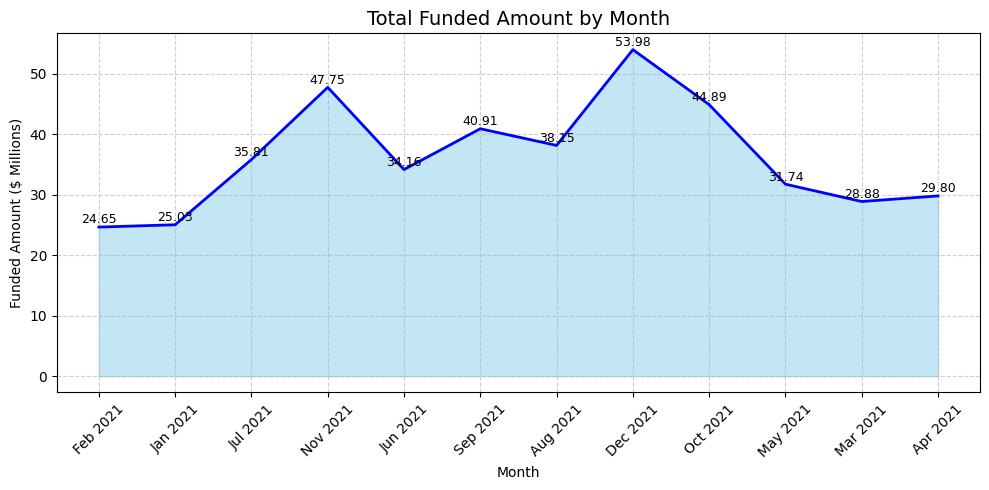

In [76]:
import matplotlib.pyplot as plt

monthly_funded = (
    df
    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['loan_amount']
    .sum()
    .div(1000000)
    .reset_index(name='loan_amount_millions')
)

plt.figure(figsize=(10, 5))

plt.fill_between(
    monthly_funded['month_name'],
    monthly_funded['loan_amount_millions'],
    color='skyblue',
    alpha=0.5
)

plt.plot(
    monthly_funded['month_name'],
    monthly_funded['loan_amount_millions'],
    color='blue',
    linewidth=2
)

for i, row in monthly_funded.iterrows():
    plt.text(
        i,
        row['loan_amount_millions'] + 0.1,
        f"{row['loan_amount_millions']:.2f}",
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=0,
        color='black'
    )

plt.title('Total Funded Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Funded Amount ($ Millions)')

plt.xticks(
    ticks=range(len(monthly_funded)),
    labels=monthly_funded['month_name'],
    rotation=45
)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Monthly trends by issue date for Total Amount Received



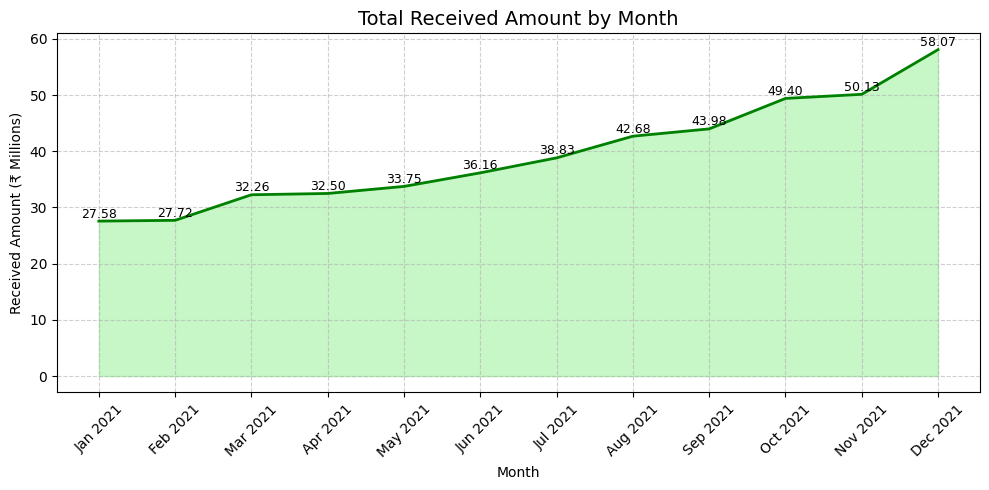

In [77]:
monthly_received = (
    df.sort_values('issue_date')
    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['total_payment']
    .sum()
    .div(1_000_000)
    .reset_index(name='received_amount_millions')
)

plt.figure(figsize=(10, 5))
plt.fill_between(monthly_received['month_name'], monthly_received['received_amount_millions'],
                 color='lightgreen', alpha=0.5)

plt.plot(monthly_received['month_name'], monthly_received['received_amount_millions'],
         color='green', linewidth=2)

for i, row in monthly_received.iterrows():
    plt.text(i, row['received_amount_millions'] + 0.1, f"{row['received_amount_millions']:.2f}",
             ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Received Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Received Amount (₹ Millions)')
plt.xticks(ticks=range(len(monthly_received)), labels=monthly_received['month_name'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


monthly_applications = (
    df.sort_values('issue_date')
    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['id']
    .count()
    .reset_index(name='loan_applications_count')
)

## Monthly trends by issue date for Total Loan Applications

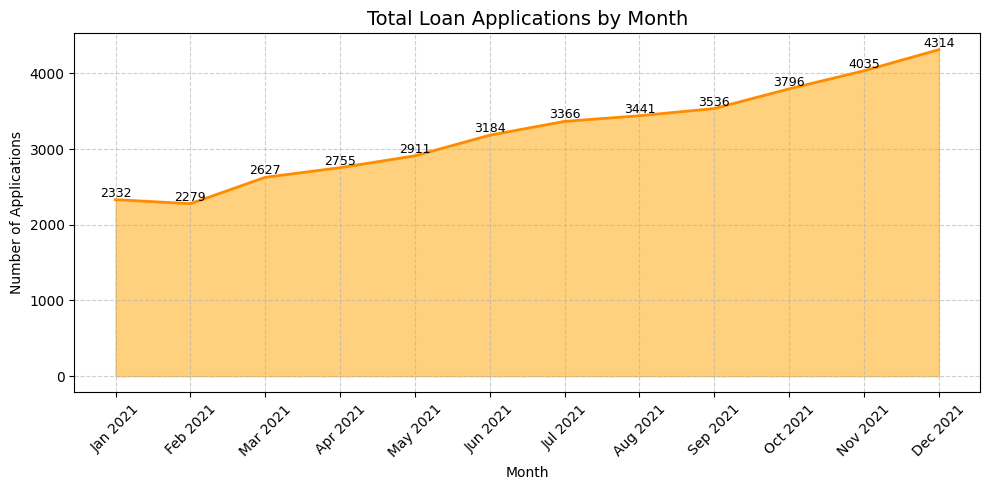

In [79]:
# Monthly trends by issue date for Total Loan Applications
monthly_applications = (
    df.sort_values('issue_date')
    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['id']
    .count()
    .reset_index(name='loan_applications_count')
)

plt.figure(figsize=(10, 5))
plt.fill_between(
    monthly_applications['month_name'],
    monthly_applications['loan_applications_count'],
    color='orange',
    alpha=0.5
)
plt.plot(
    monthly_applications['month_name'],
    monthly_applications['loan_applications_count'],
    color='darkorange',
    linewidth=2
)

for i, row in monthly_applications.iterrows():
    plt.text(
        i,
        row['loan_applications_count'] + 0.5,
        f"{row['loan_applications_count']}",
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=0,
        color='black'
    )

plt.title('Total Loan Applications by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.xticks(ticks=range(len(monthly_applications)), labels=monthly_applications['month_name'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Regional Analysis by state for total funding.

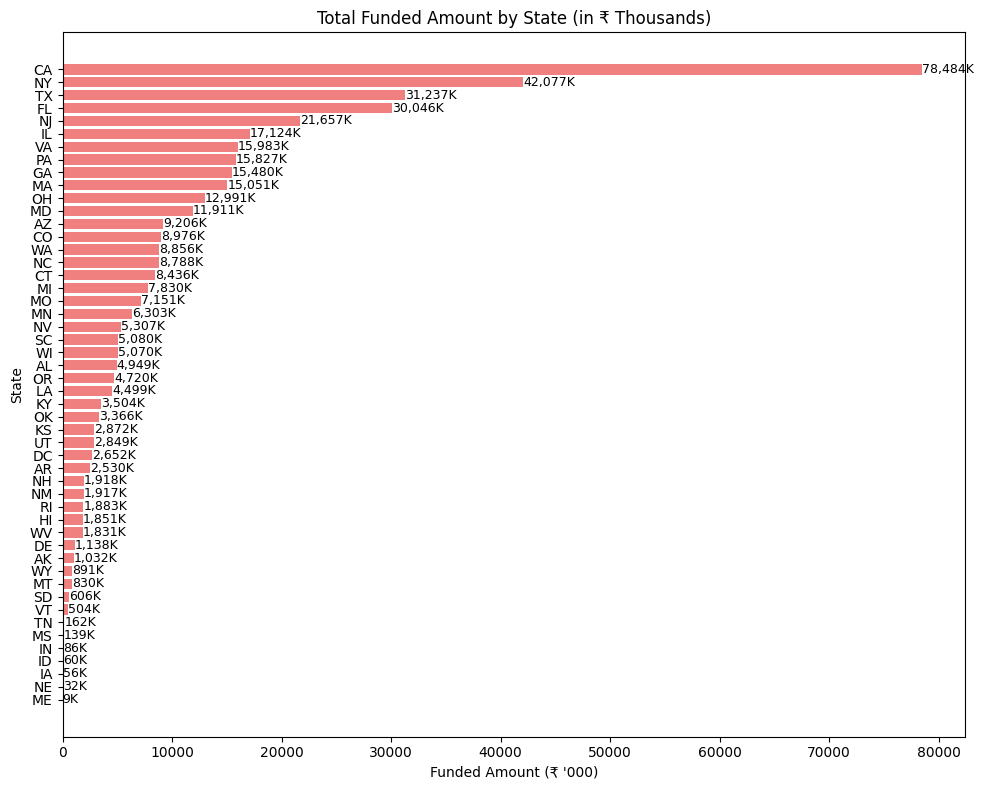

In [80]:
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_thousands = state_funding / 1000

plt.figure(figsize=(10, 8))
bars = plt.barh(state_funding_thousands.index, state_funding_thousands.values, color='lightcoral')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
             f'{width:,.0f}K', va='center', fontsize=9)

plt.title('Total Funded Amount by State (in ₹ Thousands)')
plt.xlabel("Funded Amount (₹ '000)")
plt.ylabel('State')
plt.tight_layout()
plt.show()

## Regional Analysis by state for total Amount Received.

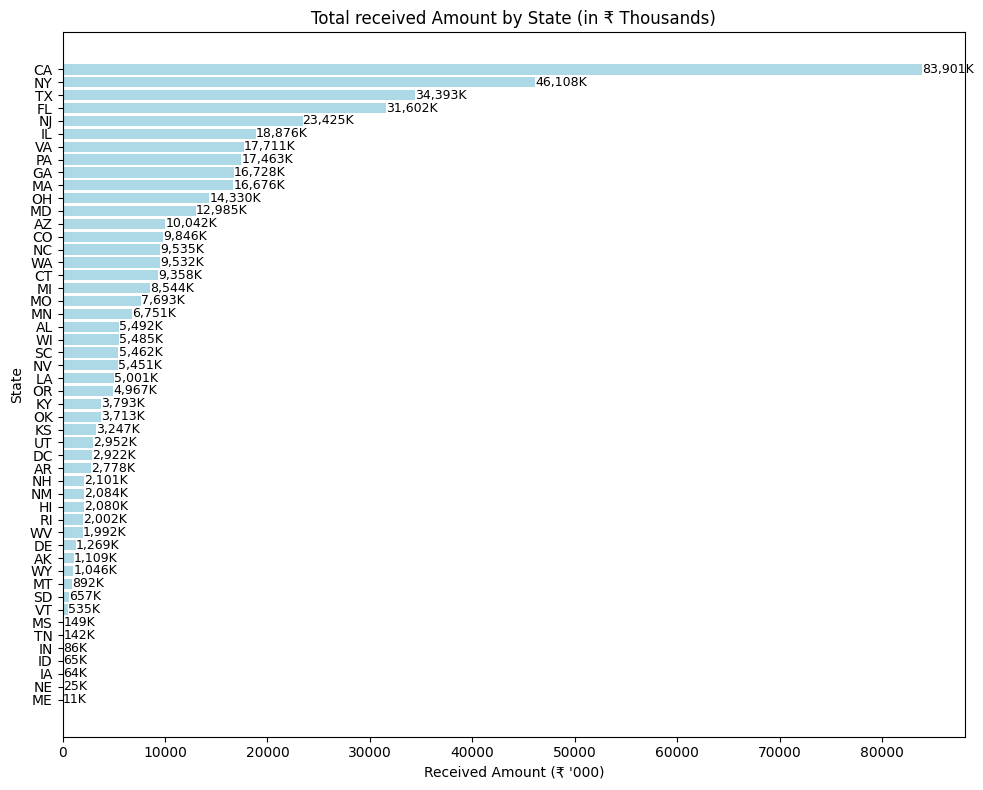

In [82]:
amount_received = df.groupby('address_state')['total_payment'].sum().sort_values(ascending=True)
amount_received_thousands = amount_received / 1000

plt.figure(figsize=(10, 8))
bars = plt.barh(amount_received_thousands.index, amount_received_thousands.values, color='lightblue')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2, f'{width:,.0f}K', va='center', fontsize=9)

plt.title('Total received Amount by State (in ₹ Thousands)')
plt.xlabel("Received Amount (₹ '000)")
plt.ylabel('State')
plt.tight_layout()
plt.show()

## Loan term analysis by total funding amount

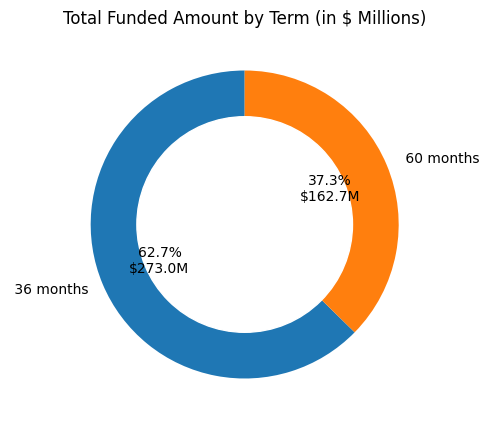

In [83]:
term_funding_millions = df.groupby('term')['loan_amount'].sum() / 1000000

plt.figure(figsize=(5, 5))
plt.pie(
    term_funding_millions,
    labels=term_funding_millions.index,
    autopct=lambda p: f"{p:.1f}%\n${p*sum(term_funding_millions)/100:.1f}M",
    startangle=90,
    wedgeprops={'width': 0.4}
)
plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))
plt.title("Total Funded Amount by Term (in $ Millions)")
plt.show()

## Employee Length by total funding amount

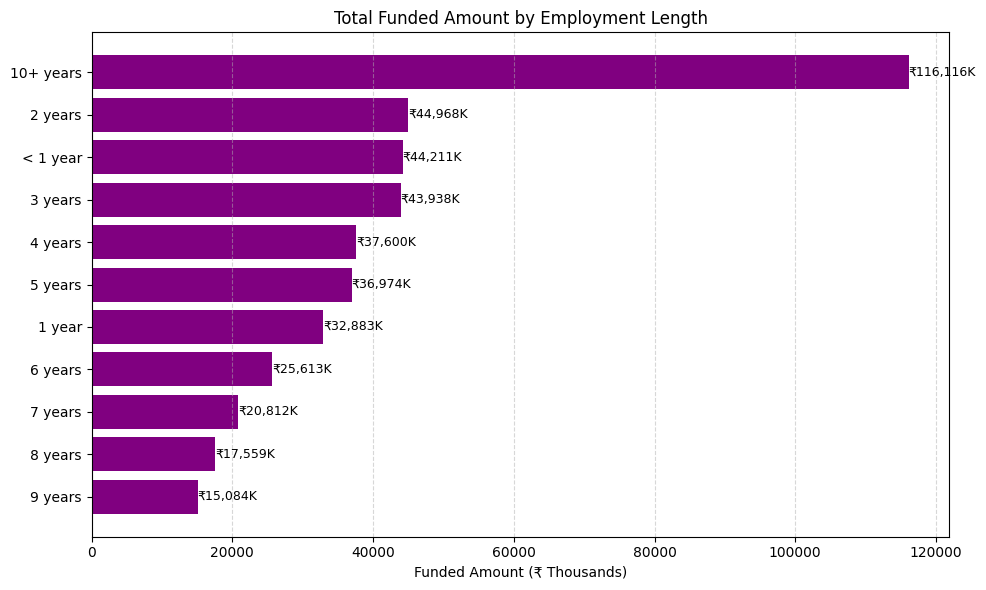

In [84]:
emp_funding_thousands = df.groupby('emp_length')['loan_amount'].sum().sort_values()/1000

plt.figure(figsize=(10, 6))
bars = plt.barh(emp_funding_thousands.index, emp_funding_thousands, color='purple')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height() / 2,
             f'₹{width:,.0f}K', va='center', fontsize=9)

plt.xlabel("Funded Amount (₹ Thousands)")
plt.title("Total Funded Amount by Employment Length")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



## Loan purpose by total funding amount

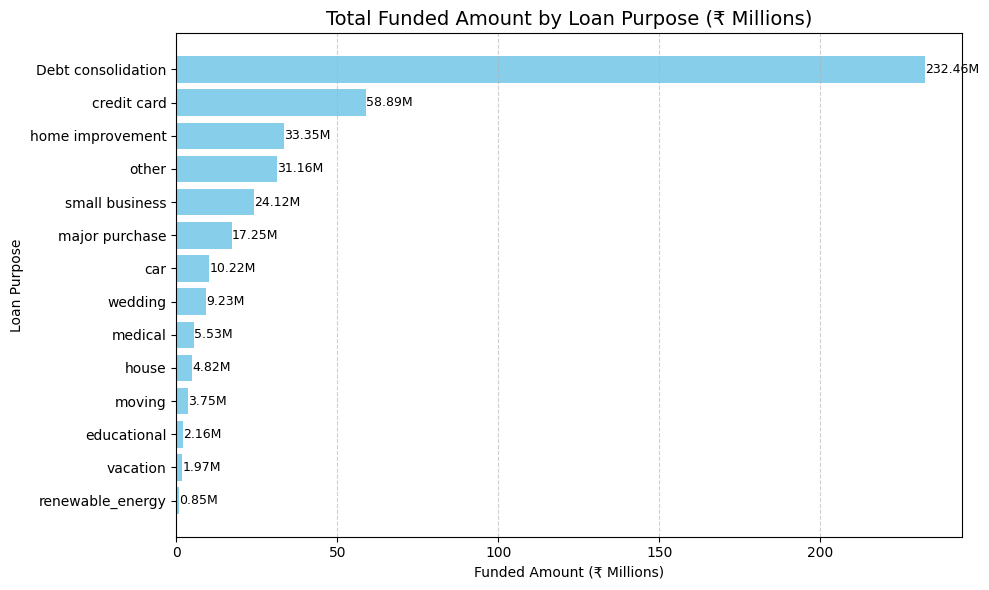

In [85]:
purpose_funding_millions = (df.groupby('purpose')['loan_amount'].sum().sort_values() / 1000000)

plt.figure(figsize=(10, 6))
bars = plt.barh(purpose_funding_millions.index, purpose_funding_millions.values, color='skyblue')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{width:.2f}M', va='center', fontsize=9)

plt.title('Total Funded Amount by Loan Purpose (₹ Millions)', fontsize=14)
plt.xlabel('Funded Amount (₹ Millions)')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



## Home Ownership by total funding amount

In [86]:
home_funding = df.groupby('home_ownership')['loan_amount'].sum().reset_index()
home_funding['loan_amount_millions'] = home_funding['loan_amount'] / 1000000

fig = px.treemap(
    home_funding,
    path=['home_ownership'],
    values='loan_amount_millions',
    color='loan_amount_millions',
    color_continuous_scale='Blues',
    title='Total Funded Amount by Home Ownership (₹ Millions)'
)

fig.show()